In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

# Make plots look professional
plt.style.use('seaborn-v0_8-darkgrid')

# Load the data we generated in Phase 1
print("Loading data...")
df = pd.read_csv('../data/energy_data_2024_2025.csv', parse_dates=['timestamp'], index_col='timestamp')

# Drop any accidental missing values (XGBoost can handle NaNs, but it's better to be clean)
df = df.dropna()
print(f"Data loaded successfully! Shape: {df.shape}")

Loading data...
Data loaded successfully! Shape: (17544, 5)


In [ ]:
# 1. Extract Time Features
df['hour'] = df.index.hour # type: ignore
df['day_of_week'] = df.index.dayofweek # type: ignore
df['month'] = df.index.month # type: ignore
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# 2. Domain Knowledge Features (The Merit Order Effect)
df['Total_Renewable'] = df['Generation_Solar'] + df['Generation_Wind_Onshore'] + df['Generation_Wind_Offshore']
df['Renewable_Ratio'] = df['Total_Renewable'] / df['Electricity_Load'] # How much of the demand is met by free green energy?

# 3. Define our Features (X) and Target (y)
features = [
    'Electricity_Load', 'Generation_Solar', 'Generation_Wind_Onshore', 
    'Generation_Wind_Offshore', 'Total_Renewable', 'Renewable_Ratio',
    'hour', 'day_of_week', 'month', 'is_weekend'
]
target = 'Wholesale_Prices'

X = df[features]
y = df[target]

print("Features mapped. Ready for training.")

Features mapped. Ready for training.


In [3]:
# Split chronologically (shuffle=False is mandatory for Time Series!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training on {len(X_train)} hours (Past)...")
print(f"Testing on {len(X_test)} hours (Future)...")

# Initialize the XGBoost Regressor
# These hyperparameters (n_estimators, learning_rate) control how fast/deep the AI learns
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
)

# Train the model
model.fit(X_train, y_train)
print("✅ AI Model Training Complete!")

Training on 14035 hours (Past)...
Testing on 3509 hours (Future)...
✅ AI Model Training Complete!


--- AI REPORT CARD ---
Mean Absolute Error (MAE): €17.56 per MWh
R-Squared (Accuracy): 0.67
----------------------


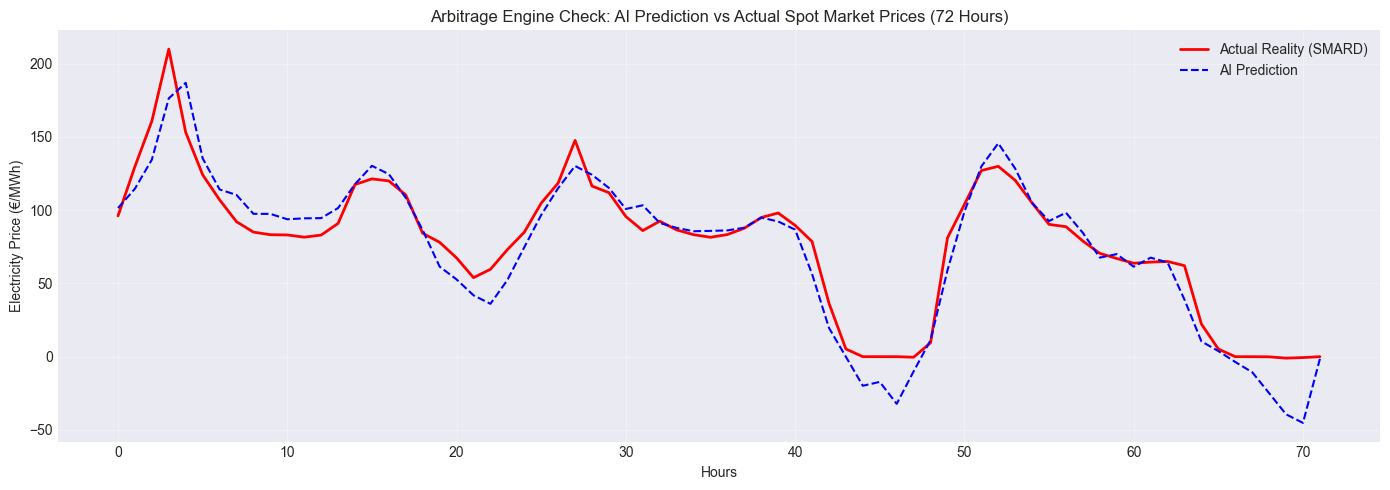

In [4]:
# Make predictions on the unseen test set
predictions = model.predict(X_test)

# Calculate Error Metrics
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("--- AI REPORT CARD ---")
print(f"Mean Absolute Error (MAE): €{mae:.2f} per MWh")
print(f"R-Squared (Accuracy): {r2:.2f}")
print("----------------------")

# Visualize: AI Prediction vs. Reality (Zoom in on a random 72-hour window)
start_idx = 500
end_idx = start_idx + 72

plt.figure(figsize=(14, 5))
plt.plot(y_test.values[start_idx:end_idx], label='Actual Reality (SMARD)', color='red', linewidth=2)
plt.plot(predictions[start_idx:end_idx], label='AI Prediction', color='blue', linestyle='--')
plt.title('Arbitrage Engine Check: AI Prediction vs Actual Spot Market Prices (72 Hours)')
plt.ylabel('Electricity Price (€/MWh)')
plt.xlabel('Hours')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
import joblib
import os

# Create a folder for your saved models if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the trained XGBoost model
joblib.dump(model, '../models/xgboost_price_predictor_v1.joblib')

print("💾 Model successfully saved to: models/xgboost_price_predictor_v1.joblib")


💾 Model successfully saved to: models/xgboost_price_predictor_v1.joblib
